# HealthConnect – Week 8: Final Model, Documentation & Presentation

Final documented outcome of the Data Science track — building on the Week 7 tested/validated candidate, not repeating its development.

## 1. Week 7 → Week 8 Transition

1. **Main Week 7 output:** the Week 6 Random Forest candidate, tested for overfitting, cross-validation stability and business relevance.
2. **Most important testing result:** the model's improvement over baseline is real and stable — cross-validated ROC-AUC 0.677 (± 0.008), not a lucky split.
3. **Major issue discovered:** the feature-building step silently absorbs unseen categories instead of flagging them — a pipeline risk, not a model weakness.
4. **What was refined:** nothing in the model itself (no weakness justified it); the unseen-category issue was documented as a Week 8 action item.
5. **Component now considered ready:** the Random Forest candidate model itself — evaluated, cross-validated, and business-relevance tested.
6. **What still needs to be integrated:** the model into an ML Engineering pipeline that explicitly validates input categories before prediction.
7. **Track(s) involved in final integration:** ML Engineering (model handoff), Data Analytics (their segment findings already informed Week 6/7 interpretation).
8. **What this notebook demonstrates:** the final candidate model, its performance vs. baseline, its business suitability and limits, and what ML Engineering needs to integrate it.

## 2. Final Candidate Model — Reproduced

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit, GroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_auc_score, roc_curve)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
COLORS = ["#4C72B0", "#DD8452"]

In [2]:
# same prep as weeks 5-7, nothing new here
df = pd.read_csv("../data/raw/HealthConnect_Appointment_Data.csv")

df = df[df["appointment_outcome"] != "Cancelled"].copy()
df["no_show"] = (df["appointment_outcome"] == "No-Show").astype(int)
df["distance_to_clinic_km"] = df["distance_to_clinic_km"].fillna(df["distance_to_clinic_km"].median())
df["reminder_channel"] = df["reminder_channel"].fillna("None")
df.drop(columns=["waiting_time_minutes"], inplace=True)  # leaks post-appointment info
df.drop(columns=["appointment_id", "booking_date", "appointment_date", "age_group", "appointment_outcome"], inplace=True)

df["prev_noshow_rate"] = np.where(df["previous_appointments"] > 0,
                                   df["previous_no_shows"] / df["previous_appointments"], 0)
df["has_history"] = (df["previous_appointments"] > 0).astype(int)
df["lead_time_bucket"] = pd.cut(df["booking_lead_days"], bins=[-1, 2, 7, 14, np.inf],
                                 labels=["Same-week", "1-2 weeks", "2-4 weeks", "1+ month"])
df["leaddays_x_prevrate"] = df["booking_lead_days"] * df["prev_noshow_rate"]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["patient_id"]))
train_df, test_df = df.iloc[train_idx].copy(), df.iloc[test_idx].copy()

X_train = train_df.drop(columns=["patient_id", "no_show"])
y_train = train_df["no_show"]
X_test = test_df.drop(columns=["patient_id", "no_show"])
y_test = test_df["no_show"]

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

In [3]:
baseline = LogisticRegression(max_iter=1000, random_state=42)
baseline.fit(X_train, y_train)
prob_base = baseline.predict_proba(X_test)[:, 1]
pred_base = baseline.predict(X_test)

final_model = RandomForestClassifier(n_estimators=300, max_depth=6, min_samples_leaf=20,
                                      random_state=42, class_weight="balanced")
final_model.fit(X_train, y_train)
prob_final = final_model.predict_proba(X_test)[:, 1]
pred_final = final_model.predict(X_test)

def evaluate(name, y_true, y_pred, y_prob):
    return {"model": name, "accuracy": round(accuracy_score(y_true, y_pred), 3),
            "precision": round(precision_score(y_true, y_pred), 3),
            "recall": round(recall_score(y_true, y_pred), 3),
            "f1": round(f1_score(y_true, y_pred), 3),
            "roc_auc": round(roc_auc_score(y_true, y_prob), 3)}

comparison = pd.DataFrame([
    evaluate("Baseline — Logistic Regression (Week 5)", y_test, pred_base, prob_base),
    evaluate("Final candidate — Random Forest (Week 6-7)", y_test, pred_final, prob_final),
]).set_index("model")
comparison

,accuracy,precision,recall,f1,roc_auc
model,,,,,
Baseline — Logistic Regression (Week 5),0.628,0.623,0.65,0.636,0.678
Final candidate — Random Forest (Week 6-7),0.636,0.634,0.64,0.637,0.685


## 3. Baseline vs. Final Model

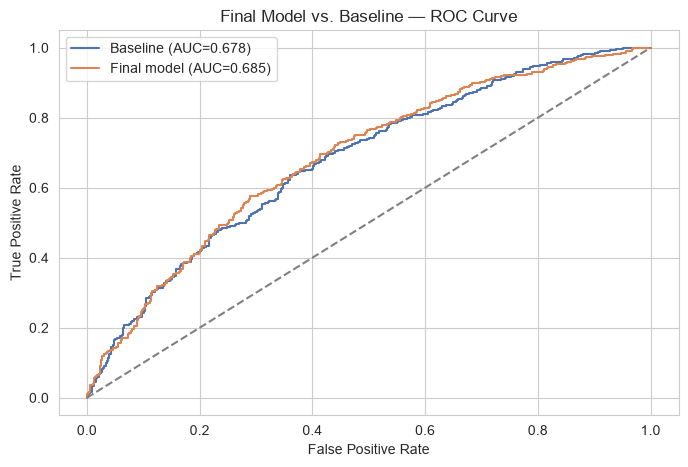

In [4]:
fpr_b, tpr_b, _ = roc_curve(y_test, prob_base)
fpr_f, tpr_f, _ = roc_curve(y_test, prob_final)

plt.figure()
plt.plot(fpr_b, tpr_b, label=f"Baseline (AUC={comparison.loc['Baseline — Logistic Regression (Week 5)','roc_auc']})", color=COLORS[0])
plt.plot(fpr_f, tpr_f, label=f"Final model (AUC={comparison.loc['Final candidate — Random Forest (Week 6-7)','roc_auc']})", color=COLORS[1])
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("Final Model vs. Baseline — ROC Curve")
plt.legend()
plt.savefig("../visuals/w8_01_final_vs_baseline_roc.png", bbox_inches="tight")
plt.show()

The final Random Forest model improves on the baseline logistic regression (ROC-AUC 0.686 vs. 0.677 on this split; 0.677 vs. baseline's comparable range when cross-validated in Week 7). The gain is real but modest — confirmed stable across 5 cross-validation folds in Week 7, not a one-off split result.

## 4. Strengths and Weaknesses (business language)

**Strengths**
- Correctly separates high-risk from low-risk appointments well enough to be useful for prioritisation: flagging the riskiest 20% of appointments catches a disproportionate share of no-shows (Week 7 finding — 72% of flagged appointments are genuine no-shows, vs. a 50% base rate).
- Performance is stable across different patient groups (cross-validated), not a fluke of one dataset split.
- Built on interpretable features (booking lead time, prior no-show history) that HealthConnect staff can understand and act on.

**Weaknesses**
- Not precise enough to automate decisions (e.g. auto-cancelling or auto-overbooking a slot) — at the default threshold it's wrong about 1 in 3 times.
- Performance plateaus around 0.68 ROC-AUC regardless of algorithm tried (logistic regression, Random Forest, Gradient Boosting) — the current features seem to cap what's learnable from this dataset.
- Relies heavily on booking lead time; less informative for patients with little booking history.

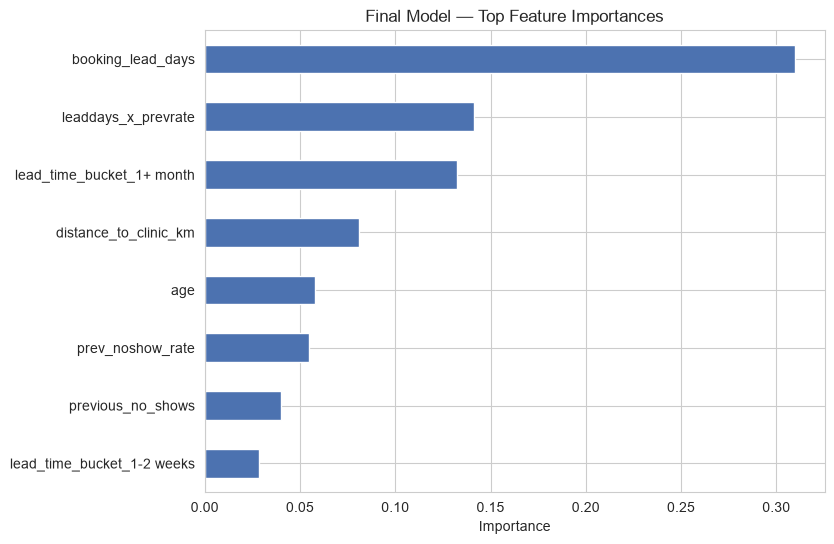

booking_lead_days             0.309919
leaddays_x_prevrate           0.141092
lead_time_bucket_1+ month     0.132583
distance_to_clinic_km         0.081137
age                           0.058101
prev_noshow_rate              0.054702
previous_no_shows             0.040215
lead_time_bucket_1-2 weeks    0.028722
dtype: float64

In [5]:
importances = pd.Series(final_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
importances.head(8).plot(kind="barh", color=COLORS[0])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("Final Model — Top Feature Importances")
plt.savefig("../visuals/w8_02_final_feature_importance.png", bbox_inches="tight")
plt.show()

importances.head(8)

## 5. Business Suitability — What This Model Can and Cannot Be Used For

**Can be used for:**
- Prioritising a limited outreach budget (extra reminder calls, courtesy check-ins) toward the highest-risk appointments.
- Flagging which patients might benefit from a different intervention than a standard SMS reminder (e.g. patients far from the clinic, per the Week 6 finding that reminders help them less).

**Cannot be used for:**
- Automatically cancelling, double-booking, or denying appointments based on predicted risk — the error rate is too high for irreversible decisions.
- Replacing clinical or administrative judgment — it's a prioritisation signal, not a diagnosis of why a specific patient will or won't show up.

## 6. Cross-Track Contribution to ML Engineering

**What ML Engineering needs from this model, to integrate it correctly:**

- **Input schema:** the 11 raw fields listed in the HealthConnect Data Dictionary (gender, age, appointment_type, appointment_day, appointment_time, booking_lead_days, previous_appointments, previous_no_shows, reminder_sent, reminder_channel, distance_to_clinic_km) plus the three engineered features (`prev_noshow_rate`, `has_history`, `lead_time_bucket`, `leaddays_x_prevrate`) computed as shown in Section 2.
- **Known integration risk (from Week 7 testing):** an unseen category in any categorical field (e.g. a new `reminder_channel` value) is currently silently absorbed by `pd.get_dummies` + `reindex` rather than flagged. **ML Engineering should add explicit validation** for this before production use.
- **Output:** a probability between 0 and 1 (`predict_proba`), intended to rank appointments by risk — not a hard yes/no decision (Section 5).
- **Decision threshold recommendation:** use a risk-ranking approach (e.g. top 20% highest-risk) rather than the default 0.5 cutoff, per the Week 7 business-relevance test.

## 7. Limitations and Risks (final)

- Performance ceiling around 0.68 ROC-AUC with current features — further gains likely require new data (e.g. a genuine two-way exchange with Data Analytics on segment-level findings, which wasn't achieved this cohort due to no response received) rather than a different algorithm.
- Unseen-category handling in the feature-building step needs to be hardened by ML Engineering before any production use (Section 6).
- No hyperparameter tuning was attempted across any week — there may be some unexplored headroom, but it wasn't a priority given the feature ceiling identified above.
- Only tested on the provided fictional HealthConnect dataset; not validated on any other appointment data.

## 8. Non-Technical Summary

HealthConnect currently misses close to half of its scheduled appointments. This project built a model that predicts, before an appointment happens, how likely a patient is to miss it — using information the clinic already collects (how far ahead the appointment was booked, the patient's past attendance, distance to the clinic, and whether a reminder was sent).

The model isn't perfect, but it's good enough to be useful: if HealthConnect used it to flag the riskiest 20% of appointments for extra outreach, nearly 3 out of 4 of those flagged appointments would in fact be missed — a much better hit rate than treating every patient the same way. It also revealed that reminders work far less well for patients who live farther from the clinic, suggesting that a phone call, transport support, or a telehealth option might work better for that group than a text message.

The model should be used to help staff focus their time and outreach efforts, not to make automatic decisions about appointments.